# Xception + CVAE + SSIM — Opción B (Colab, reestructurado)

CVAE condicional con **prior aprendido** `p(z|θ)`, usando como encoder un **backbone Xception pre-entrenado** (modelo inverso V3100) congelado salvo los últimos bloques.

```
img ──► Xception backbone (V3100, fine-tune bloques 11-14) ──► GAP ──► (B,2048)
                                                                         │
θ ──► Prior p(z|θ) ──► μ_p, logσ²_p, ce ─────────────────────────────────┤
                                                                         ▼
                                              Encoder q(z|emb,ce) ──► μ_q, logσ²_q ──► z
                                                                         │
                                              Decoder(z, ce) ──► x̂ (40×40, tanh)
```

**Loss:** `(1 − SSIM) + λ_L1·L1 + β·KLD(q‖p)` con β en rampa (épocas 1→12) y plateau.

---

### ⚠️ ANTES DE EMPEZAR — elegir GPU correcta

El error `CUDA_ERROR_INVALID_HANDLE` que aparecía no es del código: es una **incompatibilidad de TensorFlow 2.20 con las GPU L4** que asigna Colab. Las GPU **T4** y **A100** funcionan bien.

1. Menú **Runtime → Change runtime type → Hardware accelerator → T4 GPU** (o A100 si tenés Pro).
2. Ejecutar la **celda 0** (instalación) y **reiniciar el runtime**.
3. Continuar. La **celda 2 (self-test)** verifica que la GPU funcione *antes* de construir nada — si falla, te dice exactamente qué hacer.

**Datasets Kaggle:**
- `carloscanamejoy/dataset-spines-united-v2` → `dataset_unificado_v2.npz` (claves `img`, `params`, `labels`)
- `carloscanamejoy/weights-xception-model` → `modelo_xception_fulldatabaseV3100.h5`


## 0. Instalar dependencias y forzar Keras 2  *(correr una vez → REINICIAR RUNTIME)*

Keras 3 (default en Colab) tiene un bug que rompe la GPU con `Op:Cast`. Se fuerza Keras 2 con `tf-keras` + `TF_USE_LEGACY_KERAS=1` (igual que en el notebook del ViT que sí corre).


In [1]:
# Correr UNA vez y después: Runtime → Restart session
!pip install -q tf-keras kaggle

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
print("✅ Listo. REINICIA EL RUNTIME (Runtime → Restart session) y seguí desde la celda 1.")


✅ Listo. REINICIA EL RUNTIME (Runtime → Restart session) y seguí desde la celda 1.


## 1. Imports y configuración global

In [2]:
import os
# CRÍTICO: Keras 2 legacy ANTES de importar TF (evita el bug de Keras 3 en Colab)
os.environ["TF_USE_LEGACY_KERAS"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import json, time, pickle, glob, zipfile, shutil
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, Model
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, Dense, Input, Dropout, BatchNormalization,
)
from tensorflow.keras.applications import Xception
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

# ---- Semilla única para TODO el notebook ----
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---- Memory growth ----
for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print(f"WARN memory growth: {e}")

print(f"TF: {tf.__version__}")
try:
    import tf_keras
    print(f"Keras backend: tf_keras {tf_keras.__version__}  ✅ (Keras 2 legacy)")
except Exception:
    print("⚠️  tf_keras no detectado — ¿corriste la celda 0 y reiniciaste el runtime?")
print(f"GPUs: {tf.config.list_physical_devices('GPU')}")


TF: 2.20.0
Keras backend: tf_keras 2.20.0  ✅ (Keras 2 legacy)
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Self-test de GPU  *(falla rápido y claro)*

Lanza un kernel CUDA mínimo (`random` + `matmul`). Si la GPU asignada es una L4 incompatible, esto explota acá con un mensaje accionable **en vez de** morir más adelante dentro del modelo Xception.


In [3]:
def gpu_self_test():
    gpus = tf.config.list_physical_devices("GPU")
    if not gpus:
        print("⚠️  No hay GPU. El entrenamiento irá MUY lento en CPU.")
        print("    Runtime → Change runtime type → T4 GPU")
        return False
    try:
        with tf.device("/GPU:0"):
            a = tf.random.normal([512, 512])      # stateless_uniform/Sub bajo el capó
            b = tf.random.normal([512, 512])
            c = tf.matmul(a, b)                    # MatMul en GPU
            _ = float(tf.reduce_sum(c).numpy())    # fuerza ejecución
        # nombre de la GPU
        try:
            name = tf.config.experimental.get_device_details(gpus[0]).get("device_name", "GPU")
        except Exception:
            name = "GPU"
        print(f"✅ GPU OK: {name} — kernels CUDA funcionan.")
        return True
    except Exception as e:
        print("❌ La GPU asignada NO puede lanzar kernels CUDA (típico de L4 con TF 2.20).")
        print("   SOLUCIÓN: Runtime → Change runtime type → T4 GPU → Save,")
        print("   luego Runtime → Restart session y volvé a correr desde la celda 1.")
        print(f"\n   Detalle: {type(e).__name__}: {str(e)[:200]}")
        raise SystemExit("GPU incompatible — cambiá a T4 y reiniciá (ver mensaje arriba).")

_GPU_OK = gpu_self_test()


✅ GPU OK: NVIDIA A100-SXM4-40GB — kernels CUDA funcionan.


## 3. Subir `kaggle.json` y descargar dataset + pesos

In [4]:
# --- kaggle.json ---
KAGGLE_JSON = "/root/.kaggle/kaggle.json"
if not os.path.exists(KAGGLE_JSON):
    try:
        from google.colab import files
        print("⬆️  Subí tu kaggle.json:")
        up = files.upload()
        jname = next(k for k in up if k.endswith(".json"))
        os.makedirs("/root/.kaggle", exist_ok=True)
        shutil.move(jname, KAGGLE_JSON)
    except Exception as e:
        raise RuntimeError(f"Colocá kaggle.json en {KAGGLE_JSON}: {e}")
os.chmod(KAGGLE_JSON, 0o600)
print("kaggle.json OK")

# --- descargas (--unzip extrae directo) ---
os.makedirs("/content/data",    exist_ok=True)
os.makedirs("/content/weights", exist_ok=True)
!kaggle datasets download -d carloscanamejoy/dataset-spines-united-v2 -p /content/data    --unzip
!kaggle datasets download -d carloscanamejoy/weights-xception-model   -p /content/weights --unzip

DATASET_PATH     = "/content/data/dataset_unificado_v2.npz"
XCEPTION_WEIGHTS = "/content/weights/modelo_xception_fulldatabaseV3100.h5"

for tag, p in [("Dataset", DATASET_PATH), ("Pesos Xception", XCEPTION_WEIGHTS)]:
    print(("✅" if os.path.exists(p) else "❌ NO ENCONTRADO"), tag, "→", p)
assert os.path.exists(DATASET_PATH),     "Falta el dataset"
assert os.path.exists(XCEPTION_WEIGHTS), "Falta el .h5 de pesos"


⬆️  Subí tu kaggle.json:


Saving kaggle.json to kaggle.json
kaggle.json OK
Dataset URL: https://www.kaggle.com/datasets/carloscanamejoy/dataset-spines-united-v2
License(s): unknown
100% 421M/421M [00:01<00:00, 223MB/s]

Dataset URL: https://www.kaggle.com/datasets/carloscanamejoy/weights-xception-model
License(s): apache-2.0
100% 670M/670M [00:02<00:00, 240MB/s]

✅ Dataset → /content/data/dataset_unificado_v2.npz
✅ Pesos Xception → /content/weights/modelo_xception_fulldatabaseV3100.h5


## 4. Hiperparámetros (Optuna + ajustes anti-colapso Opción B) y rutas de salida

In [5]:
# --- HPs base de Optuna + 3 ajustes anti-colapso ---
LR_BACKBONE   = 1.3540658782530271e-06
LR_CVAE       = 0.000872261525233455
BETA_MAX      = 0.18      # ajuste B (era 0.4348): no aplastar el posterior
LAMBDA_L1     = 0.05      # ajuste B (era 0.0104): penalizar colapso a imagen constante
Z_DIM         = 192
COND_EMB_DIM  = 32
BATCH_SIZE    = 16

# --- Config de entrenamiento ---
EPOCHS         = 30
BETA_START     = 1e-6
BETA_RAMP_END  = 12       # β sube linealmente ép.1→12, luego plateau en BETA_MAX
COND_DIM       = 8        # nº de parámetros físicos θ
SUBSAMPLE_FRAC = 1.0    # 10% del dataset (experimento Opción B)
KL_ACTIVE_THR  = 0.01     # umbral para contar dimensiones latentes "activas"

# --- Rutas de salida ---
OUTPUT_DIR = "/content/outputs"
CKPT_DIR   = os.path.join(OUTPUT_DIR, "checkpoints")
FIG_DIR    = os.path.join(OUTPUT_DIR, "figures")
for d in (OUTPUT_DIR, CKPT_DIR, FIG_DIR):
    os.makedirs(d, exist_ok=True)

BEST_CKPT   = os.path.join(CKPT_DIR, "cvae_xception_optB_best.weights.h5")   # mejor val_gen
LAST_CKPT   = os.path.join(CKPT_DIR, "cvae_xception_optB_last.weights.h5")   # última época
SCALER_PKL  = os.path.join(OUTPUT_DIR, "param_scaler_xception_optB.pkl")
HISTORY_JSON= os.path.join(OUTPUT_DIR, "history_xception_optB.json")

print(f"z_dim={Z_DIM} cond_emb={COND_EMB_DIM} batch={BATCH_SIZE} "
      f"β_max={BETA_MAX} λL1={LAMBDA_L1}")
print(f"epochs={EPOCHS}  β-ramp ép.1→{BETA_RAMP_END}  subsample={SUBSAMPLE_FRAC*100:.0f}%")
print(f"outputs → {OUTPUT_DIR}")


z_dim=192 cond_emb=32 batch=16 β_max=0.18 λL1=0.05
epochs=30  β-ramp ép.1→12  subsample=100%
outputs → /content/outputs


## 5. Carga de datos, subsample y splits estratificados

**Reproducibilidad:** todo deriva de `SEED=42`.

**Protocolo de split** (alineado con el notebook del ViT):
1. Subsample del **10%** del dataset completo — estratificado por `labels` si existen (mantiene la proporción de estructuras magnéticas), si no, aleatorio.
2. Sobre ese 10%: split **70 / 15 / 15** (train / val / test), estratificado por label.
3. `MinMaxScaler` ajustado **sólo con train** y aplicado a val/test (sin fuga de información).


In [6]:
data = np.load(DATASET_PATH)
print("npz keys:", data.files)

imgs   = data["img"].astype(np.float32)
params = data["params"].astype(np.float32)
labels = data["labels"].astype(int) if "labels" in data.files else None
if imgs.ndim == 3:
    imgs = imgs[..., np.newaxis]

N = len(imgs)
print(f"Total: {N:,} imgs {imgs.shape[1:]}  range [{imgs.min():.2f}, {imgs.max():.2f}]"
      f"  | params dim={params.shape[1]}"
      f"  | labels={'sí' if labels is not None else 'no'}")

# 1) subsample (estratificado por label si hay). Si frac>=1.0 usamos TODO el dataset.
if SUBSAMPLE_FRAC >= 1.0:
    sub_idx = np.arange(N)
    print("Usando el 100% del dataset (sin subsample)")
else:
    n_sub = int(N * SUBSAMPLE_FRAC)
    sub_idx, _ = train_test_split(
        np.arange(N), train_size=n_sub, random_state=SEED,
        stratify=(labels if labels is not None else None))

imgs_sub       = imgs[sub_idx]
params_sub_raw = params[sub_idx]
labels_sub     = labels[sub_idx] if labels is not None else None

# 2) split 70/15/15 sobre el subsample (índices LOCALES al subsample)
loc = np.arange(len(sub_idx))
idx_train, idx_temp = train_test_split(
    loc, test_size=0.30, random_state=SEED, stratify=labels_sub)
strat_temp = labels_sub[idx_temp] if labels_sub is not None else None
idx_val, idx_test = train_test_split(
    idx_temp, test_size=0.50, random_state=SEED, stratify=strat_temp)

# 3) scaler SOLO con train
scaler = MinMaxScaler().fit(params_sub_raw[idx_train])
params_train = scaler.transform(params_sub_raw[idx_train]).astype(np.float32)
params_val   = scaler.transform(params_sub_raw[idx_val]  ).astype(np.float32)
params_test  = scaler.transform(params_sub_raw[idx_test] ).astype(np.float32)

# guardar scaler ya mismo (no depende del entrenamiento)
with open(SCALER_PKL, "wb") as f:
    pickle.dump(scaler, f)

print(f"\nSubsample: {len(sub_idx):,} ({SUBSAMPLE_FRAC*100:.0f}%)")
print(f"  train={len(idx_train):,}  val={len(idx_val):,}  test={len(idx_test):,}")
print(f"  scaler guardado → {SCALER_PKL}")


npz keys: ['img', 'params', 'labels', 'label_keys', 'label_names', 'column_names']
Total: 169,671 imgs (39, 39, 1)  range [-1.00, 1.00]  | params dim=8  | labels=sí
Usando el 100% del dataset (sin subsample)

Subsample: 169,671 (100%)
  train=118,769  val=25,451  test=25,451
  scaler guardado → /content/outputs/param_scaler_xception_optB.pkl


## 6. `tf.data` pipelines (en CPU)

El pipeline se construye dentro de `tf.device("/CPU:0")`: las operaciones de `shuffle`/`from_tensor_slices` deben vivir en CPU (en GPU disparan `Op:Equal` → `CUDA_ERROR_INVALID_HANDLE`). El `prefetch` mueve los batches a GPU a tiempo, sin costo de rendimiento. La GPU se reserva para el modelo.


In [7]:
def preprocess(img, param):
    img_xc     = tf.image.resize(img, (224, 224))     # Xception input
    img_xc     = tf.image.grayscale_to_rgb(img_xc)    # 1→3 canales
    img_target = tf.image.resize(img, (40, 40))       # target del decoder
    return img_xc, param, img_target

with tf.device("/CPU:0"):
    x_train = np.ascontiguousarray(imgs_sub[idx_train])
    x_val   = np.ascontiguousarray(imgs_sub[idx_val])

    train_ds = (
        tf.data.Dataset.from_tensor_slices((x_train, params_train))
        .shuffle(10000, seed=SEED, reshuffle_each_iteration=True)
        .batch(BATCH_SIZE)
        .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
        .prefetch(tf.data.AUTOTUNE)
    )
    val_ds = (
        tf.data.Dataset.from_tensor_slices((x_val, params_val))
        .batch(BATCH_SIZE)
        .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
        .prefetch(tf.data.AUTOTUNE)
    )

for img_xc, param, img_target in train_ds.take(1):
    print(f"img_xc:     {img_xc.shape}  [{img_xc.numpy().min():.2f}, {img_xc.numpy().max():.2f}]")
    print(f"param:      {param.shape}")
    print(f"img_target: {img_target.shape} [{img_target.numpy().min():.2f}, {img_target.numpy().max():.2f}]")


img_xc:     (16, 224, 224, 3)  [-1.00, 1.00]
param:      (16, 8)
img_target: (16, 40, 40, 1) [-0.98, 1.00]


## 7. Backbone: cargar Xception pre-entrenado (V3100)

El `.h5` de V3100 se guardó con esta cabeza de regresión:

```
Xception(include_top=False) → GAP → BN → Dropout(0.4)
    → Dense(256, relu, l2=1e-4) → BN → Dropout(0.3) → Dense(8, linear)
```

Para que `load_weights` case **nombre-a-nombre**, reconstruimos ese modelo plano en el mismo orden, cargamos los pesos, y después recortamos el backbone tomando el tensor de **entrada al GAP** (salida del Xception, `(B,7,7,2048)`).

Se usa `weights=None` (no descargamos ImageNet; los reemplazan los de V3100). Fine-tune sólo de los **bloques 11–14**; el resto congelado.


In [8]:
\
# 1) modelo plano V3100 (mismo orden de capas que el entrenamiento original)
_inp = Input(shape=(224, 224, 3), name="input_layer")
_xc  = Xception(weights=None, include_top=False, input_tensor=_inp, pooling=None)
_x = _xc.output
_x = GlobalAveragePooling2D()(_x)
_x = BatchNormalization()(_x)
_x = Dropout(0.4)(_x)
_x = Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(_x)
_x = BatchNormalization()(_x)
_x = Dropout(0.3)(_x)
_x = Dense(8, activation="linear")(_x)
_temp = Model(_inp, _x, name="functional")

# 2) cargar pesos V3100
_temp.load_weights(XCEPTION_WEIGHTS)
print(f"✅ Pesos V3100 cargados: {XCEPTION_WEIGHTS}")

# 3) recortar backbone: input → entrada del GAP (salida del Xception)
gap_layer = next(l for l in _temp.layers if isinstance(l, GlobalAveragePooling2D))
backbone = Model(_temp.input, gap_layer.input, name="xception_backbone")
print(f"Backbone: {backbone.input_shape} → {backbone.output_shape}")
del _temp

# 4) fine-tune sólo bloques 11-14
TRAINABLE_BLOCKS = {11, 12, 13, 14}
def _is_trainable(name):
    if not name.startswith("block"):
        return False
    num = ""
    for ch in name[5:]:
        if ch.isdigit(): num += ch
        else: break
    return bool(num) and int(num) in TRAINABLE_BLOCKS

n_tr = 0
for l in backbone.layers:
    l.trainable = _is_trainable(l.name)
    n_tr += int(l.trainable)
print(f"Backbone: {n_tr}/{len(backbone.layers)} capas entrenables "
      f"({len(backbone.trainable_variables)} vars) | bloques 11-14")


✅ Pesos V3100 cargados: /content/weights/modelo_xception_fulldatabaseV3100.h5
Backbone: (None, 224, 224, 3) → (None, 7, 7, 2048)
Backbone: 31/132 capas entrenables (40 vars) | bloques 11-14


## 8. Definición del CVAE (encoder, prior aprendido, decoder)

In [9]:
class Sampling(layers.Layer):
    def call(self, inputs):
        mu, lv = inputs
        eps = tf.random.normal(tf.shape(mu))
        return mu + eps * tf.exp(0.5 * lv)


class Encoder(layers.Layer):
    def __init__(self, z_dim, cond_emb_dim, **kw):
        super().__init__(**kw)
        self.fc1 = Dense(512, activation="silu")
        self.fc2 = Dense(256, activation="silu")
        self.fc_mu = Dense(z_dim)
        self.fc_lv = Dense(z_dim)
        self.sampling = Sampling()
    def call(self, emb, ce):
        h = tf.concat([emb, ce], axis=-1)
        h = self.fc2(self.fc1(h))
        mu, lv = self.fc_mu(h), self.fc_lv(h)
        return mu, lv, self.sampling([mu, lv])


class Prior(layers.Layer):
    """Prior aprendido p(z|θ)."""
    def __init__(self, z_dim, cond_emb_dim, **kw):
        super().__init__(**kw)
        self.cond_net = keras.Sequential([
            Dense(64,  activation="silu"),
            Dense(128, activation="silu"),
            Dense(cond_emb_dim, activation="silu"),
        ])
        self.fc_mu = Dense(z_dim)
        self.fc_lv = Dense(z_dim)
    def call(self, y):
        ce = self.cond_net(y)
        return self.fc_mu(ce), self.fc_lv(ce), ce


class Decoder(layers.Layer):
    def __init__(self, cond_emb_dim, **kw):
        super().__init__(**kw)
        self.fc_in   = Dense(512 * 5 * 5, activation="silu")
        self.reshape = layers.Reshape((5, 5, 512))
        self.up1 = layers.Conv2DTranspose(256, 4, strides=2, padding="same"); self.bn1 = layers.BatchNormalization()
        self.up2 = layers.Conv2DTranspose(128, 4, strides=2, padding="same"); self.bn2 = layers.BatchNormalization()
        self.up3 = layers.Conv2DTranspose(64,  4, strides=2, padding="same"); self.bn3 = layers.BatchNormalization()
        self.res1_c1 = layers.Conv2D(64, 3, padding="same"); self.res1_c2 = layers.Conv2D(64, 3, padding="same")
        self.res2_c1 = layers.Conv2D(64, 3, padding="same"); self.res2_c2 = layers.Conv2D(64, 3, padding="same")
        self.out_conv = layers.Conv2D(1, 1, activation="tanh")
    def call(self, z, ce, training=None):
        x = self.reshape(self.fc_in(tf.concat([z, ce], axis=-1)))
        x = tf.nn.silu(self.bn1(self.up1(x), training=training))
        x = tf.nn.silu(self.bn2(self.up2(x), training=training))
        x = tf.nn.silu(self.bn3(self.up3(x), training=training))
        h = tf.nn.silu(self.res1_c1(x)); x = tf.nn.silu(x + self.res1_c2(h))
        h = tf.nn.silu(self.res2_c1(x)); x = tf.nn.silu(x + self.res2_c2(h))
        return self.out_conv(x)


class CVAE_Xception(Model):
    def __init__(self, backbone, z_dim, cond_dim, cond_emb_dim, **kw):
        super().__init__(**kw)
        self.backbone = backbone
        self.gap      = GlobalAveragePooling2D()
        self.encoder  = Encoder(z_dim, cond_emb_dim)
        self.prior    = Prior(z_dim, cond_emb_dim)
        self.decoder  = Decoder(cond_emb_dim)
    def call(self, inputs, training=None):
        img_xc, y = inputs
        emb = self.gap(self.backbone(img_xc, training=training))
        mu_p, lv_p, ce = self.prior(y)
        mu_q, lv_q, z  = self.encoder(emb, ce)
        x_hat = self.decoder(z, ce, training=training)
        return x_hat, mu_q, lv_q, mu_p, lv_p
    def generate(self, y):
        """Generación desde el prior: z = μ_p (determinista)."""
        mu_p, lv_p, ce = self.prior(y)
        return self.decoder(mu_p, ce, training=False)


model = CVAE_Xception(backbone, Z_DIM, COND_DIM, COND_EMB_DIM)
_ = model([tf.zeros((1, 224, 224, 3)), tf.zeros((1, COND_DIM))], training=False)  # build

print(f"Total params:    {model.count_params():,}")
print(f"Backbone params: {backbone.count_params():,}")
print(f"CVAE params:     {model.count_params() - backbone.count_params():,}")


Total params:    27,965,193
Backbone params: 20,861,480
CVAE params:     7,103,713


## 9. Loss y pasos de entrenamiento / validación

**Reconstrucción:** `recon = (1 − SSIM) + λ_L1 · L1` (imágenes en `[-1,1]`, SSIM sobre `[0,1]`).
**KLD** entre posterior `q(z|·)` y prior aprendido `p(z|θ)` (forma analítica gaussiana).
**Optimización separada:** Adam distinto para backbone (LR muy bajo) y para el resto del CVAE; clip de gradiente a norma 1.

**Métricas de validación que se registran por época:**
- `val_recon` — recon con z del posterior.
- `val_gen` — recon con z = μ_p (generación desde el prior) → **métrica de selección del best**.
- `val_kld` — divergencia KL.
- `kl_active` — fracción de dims latentes activas (KLD > umbral).
- `var_q` — varianza media del posterior.
- `mu_gap` — distancia ‖μ_q − μ_p‖ (acoplamiento posterior-prior).


In [10]:
opt_backbone = keras.optimizers.Adam(learning_rate=LR_BACKBONE)
opt_cvae     = keras.optimizers.Adam(learning_rate=LR_CVAE)

backbone_vars = model.backbone.trainable_variables
cvae_vars = (model.encoder.trainable_variables + model.prior.trainable_variables +
             model.decoder.trainable_variables + model.gap.trainable_variables)
print(f"backbone vars: {len(backbone_vars)} | cvae vars: {len(cvae_vars)}")


def ssim_loss(y_true, y_pred):
    a = (y_true + 1.0) / 2.0
    b = (y_pred + 1.0) / 2.0
    return 1.0 - tf.image.ssim(a, b, max_val=1.0)


def kl_per_dim_fn(mu_q, lv_q, mu_p, lv_p):
    vq, vp = tf.exp(lv_q), tf.exp(lv_p)
    return 0.5 * (lv_p - lv_q + (vq + tf.square(mu_q - mu_p)) / vp - 1.0)


@tf.function
def train_step(img_xc, y, img_target, beta):
    with tf.GradientTape() as tape:
        x_hat, mu_q, lv_q, mu_p, lv_p = model([img_xc, y], training=True)
        ssim_val = tf.reduce_mean(ssim_loss(img_target, x_hat))
        l1_val   = tf.reduce_mean(tf.abs(x_hat - img_target))
        recon    = ssim_val + LAMBDA_L1 * l1_val
        kld  = tf.reduce_mean(kl_per_dim_fn(mu_q, lv_q, mu_p, lv_p))
        loss = recon + beta * kld

    grads = tape.gradient(loss, backbone_vars + cvae_vars)
    gb, gc = grads[:len(backbone_vars)], grads[len(backbone_vars):]
    gb = [tf.clip_by_norm(g, 1.0) if g is not None else g for g in gb]
    gc = [tf.clip_by_norm(g, 1.0) if g is not None else g for g in gc]
    opt_backbone.apply_gradients([(g, v) for g, v in zip(gb, backbone_vars) if g is not None])
    opt_cvae.apply_gradients(    [(g, v) for g, v in zip(gc, cvae_vars)     if g is not None])
    return loss, recon, kld


@tf.function
def val_step(img_xc, y, img_target):
    x_hat, mu_q, lv_q, mu_p, lv_p = model([img_xc, y], training=False)
    recon = tf.reduce_mean(ssim_loss(img_target, x_hat)) + LAMBDA_L1 * tf.reduce_mean(tf.abs(x_hat - img_target))

    kpd = kl_per_dim_fn(mu_q, lv_q, mu_p, lv_p)
    kld = tf.reduce_mean(kpd)

    x_gen = model.generate(y)
    gen   = tf.reduce_mean(ssim_loss(img_target, x_gen)) + LAMBDA_L1 * tf.reduce_mean(tf.abs(x_gen - img_target))

    kl_mean = tf.reduce_mean(kpd, axis=0)
    active  = tf.reduce_mean(tf.cast(kl_mean > KL_ACTIVE_THR, tf.float32))
    var_q   = tf.reduce_mean(tf.exp(lv_q))
    gap     = tf.reduce_mean(tf.sqrt(tf.reduce_sum(tf.square(mu_q - mu_p), axis=1)))
    return recon, kld, gen, active, var_q, gap


backbone vars: 40 | cvae vars: 42


## 10. Training loop

β: rampa lineal `BETA_START → BETA_MAX` (épocas 1→`BETA_RAMP_END`), después plateau.
Se guarda el **best** por menor `val_gen` y al final el **last**.


In [11]:
hist = {k: [] for k in
        ["train_loss", "train_recon", "train_kld",
         "val_recon", "val_kld", "val_gen", "kl_active", "var_q", "mu_gap", "beta"]}
best_gen = float("inf")

print("="*72)
print(f"Xception+CVAE OptB | β {BETA_START}→{BETA_MAX} (ramp 1-{BETA_RAMP_END}) | "
      f"{EPOCHS} ep | {len(idx_train):,} train imgs")
print(f"LR_backbone={LR_BACKBONE:.2e}  LR_cvae={LR_CVAE:.2e}  λL1={LAMBDA_L1}")
print("="*72)

t_glob = time.time()
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    if epoch <= BETA_RAMP_END:
        p = (epoch - 1) / max(1, BETA_RAMP_END - 1)
        beta = BETA_START + (BETA_MAX - BETA_START) * p
    else:
        beta = BETA_MAX
    beta_t = tf.constant(beta, tf.float32)

    # --- train ---
    tl = tr = tk = 0.0; nb = 0
    for img_xc, prm, tgt in train_ds:
        loss, rec, kld = train_step(img_xc, prm, tgt, beta_t)
        tl += float(loss); tr += float(rec); tk += float(kld); nb += 1
    tl/=nb; tr/=nb; tk/=nb

    # --- val ---
    vr = vk = vg = va = vv = vgap = 0.0; nv = 0
    for img_xc, prm, tgt in val_ds:
        r, k, g, a, v, gap = val_step(img_xc, prm, tgt)
        vr+=float(r); vk+=float(k); vg+=float(g); va+=float(a); vv+=float(v); vgap+=float(gap); nv+=1
    vr/=nv; vk/=nv; vg/=nv; va/=nv; vv/=nv; vgap/=nv

    for kk, vv2 in zip(hist.keys(), [tl, tr, tk, vr, vk, vg, va, vv, vgap, beta]):
        hist[kk].append(vv2)

    tag = ""
    if vg < best_gen:
        best_gen = vg
        model.save_weights(BEST_CKPT)
        tag += " *best"
    if va < 0.15:
        tag += " COLLAPSE"

    print(f"Ep[{epoch:3d}/{EPOCHS}] β={beta:.4f} | rec={tr:.4f} kld={tk:.4f} | "
          f"Vr={vr:.4f} Vk={vk:.4f} Vg={vg:.4f} | act={va:.2f} gap={vgap:.1f} vQ={vv:.3f} | "
          f"{time.time()-t0:.0f}s{tag}")

model.save_weights(LAST_CKPT)
with open(HISTORY_JSON, "w") as f:
    json.dump(hist, f, indent=2)

print(f"\nDone {(time.time()-t_glob)/60:.1f} min | best val_gen={best_gen:.4f}")
print(f"best → {BEST_CKPT}\nlast → {LAST_CKPT}\nhist → {HISTORY_JSON}")


Xception+CVAE OptB | β 1e-06→0.18 (ramp 1-12) | 30 ep | 118,769 train imgs
LR_backbone=1.35e-06  LR_cvae=8.72e-04  λL1=0.05


Ep[  1/30] β=0.0000 | rec=0.7035 kld=161.8012 | Vr=0.5331 Vk=3.2657 Vg=0.9137 | act=1.00 gap=42.4 vQ=0.628 | 281s *best


Ep[  2/30] β=0.0164 | rec=0.5073 kld=0.4782 | Vr=0.4480 Vk=0.4632 Vg=0.8591 | act=1.00 gap=21.9 vQ=2.001 | 253s *best


Ep[  3/30] β=0.0327 | rec=0.4364 kld=0.3084 | Vr=0.4049 Vk=0.3193 Vg=0.8572 | act=1.00 gap=20.2 vQ=2.057 | 253s *best


Ep[  4/30] β=0.0491 | rec=0.3958 kld=0.2402 | Vr=0.3720 Vk=0.2332 Vg=0.8210 | act=1.00 gap=18.3 vQ=1.946 | 253s *best
Ep[  5/30] β=0.0655 | rec=0.3693 kld=0.1957 | Vr=0.3524 Vk=0.2008 Vg=0.8264 | act=1.00 gap=18.7 vQ=1.897 | 253s
Ep[  6/30] β=0.0818 | rec=0.3514 kld=0.1659 | Vr=0.3406 Vk=0.1639 Vg=0.8363 | act=1.00 gap=18.3 vQ=1.900 | 252s
Ep[  7/30] β=0.0982 | rec=0.3562 kld=0.1401 | Vr=0.3758 Vk=0.1320 Vg=0.8377 | act=0.99 gap=18.2 vQ=1.796 | 251s
Ep[  8/30] β=0.1145 | rec=0.4076 kld=0.1169 | Vr=0.3429 Vk=0.1204 Vg=0.8401 | act=0.97 gap=19.2 vQ=1.667 | 252s
Ep[  9/30] β=0.1309 | rec=0.4039 kld=0.1020 | Vr=0.3616 Vk=0.1042 Vg=0.8281 | act=0.92 gap=19.3 vQ=1.550 | 252s
Ep[ 10/30] β=0.1473 | rec=0.3834 kld=0.0910 | Vr=0.3440 Vk=0.0870 Vg=0.8323 | act=0.77 gap=19.4 vQ=1.485 | 252s
Ep[ 11/30] β=0.1636 | rec=0.3850 kld=0.0816 | Vr=0.3301 Vk=0.0758 Vg=0.8293 | act=0.62 gap=19.5 vQ=1.405 | 252s
Ep[ 12/30] β=0.1800 | rec=0.3709 kld=0.0760 | Vr=1.2046 Vk=0.0765 Vg=0.9686 | act=0.59 gap=20.1 vQ

Ep[ 24/30] β=0.1800 | rec=0.3480 kld=0.0663 | Vr=0.3007 Vk=0.0647 Vg=0.8129 | act=0.18 gap=18.9 vQ=0.694 | 252s *best


Ep[ 25/30] β=0.1800 | rec=0.3088 kld=0.0677 | Vr=0.2894 Vk=0.0684 Vg=0.8078 | act=0.17 gap=18.9 vQ=0.603 | 252s *best


Ep[ 26/30] β=0.1800 | rec=0.2799 kld=0.0680 | Vr=0.2858 Vk=0.0681 Vg=0.7959 | act=0.16 gap=18.5 vQ=0.577 | 252s *best
Ep[ 27/30] β=0.1800 | rec=0.2900 kld=0.0677 | Vr=0.2943 Vk=0.0651 Vg=0.8055 | act=0.14 gap=18.1 vQ=0.579 | 253s COLLAPSE
Ep[ 28/30] β=0.1800 | rec=0.3182 kld=0.0668 | Vr=0.2905 Vk=0.0654 Vg=0.8003 | act=0.14 gap=17.9 vQ=0.551 | 253s COLLAPSE
Ep[ 29/30] β=0.1800 | rec=0.3065 kld=0.0669 | Vr=0.4422 Vk=0.0685 Vg=0.8259 | act=0.14 gap=18.0 vQ=0.518 | 253s COLLAPSE
Ep[ 30/30] β=0.1800 | rec=0.3196 kld=0.0665 | Vr=0.2863 Vk=0.0662 Vg=0.8057 | act=0.14 gap=17.8 vQ=0.526 | 253s COLLAPSE



Done 126.6 min | best val_gen=0.7959
best → /content/outputs/checkpoints/cvae_xception_optB_best.weights.h5
last → /content/outputs/checkpoints/cvae_xception_optB_last.weights.h5
hist → /content/outputs/history_xception_optB.json


## 11. Curvas de entrenamiento

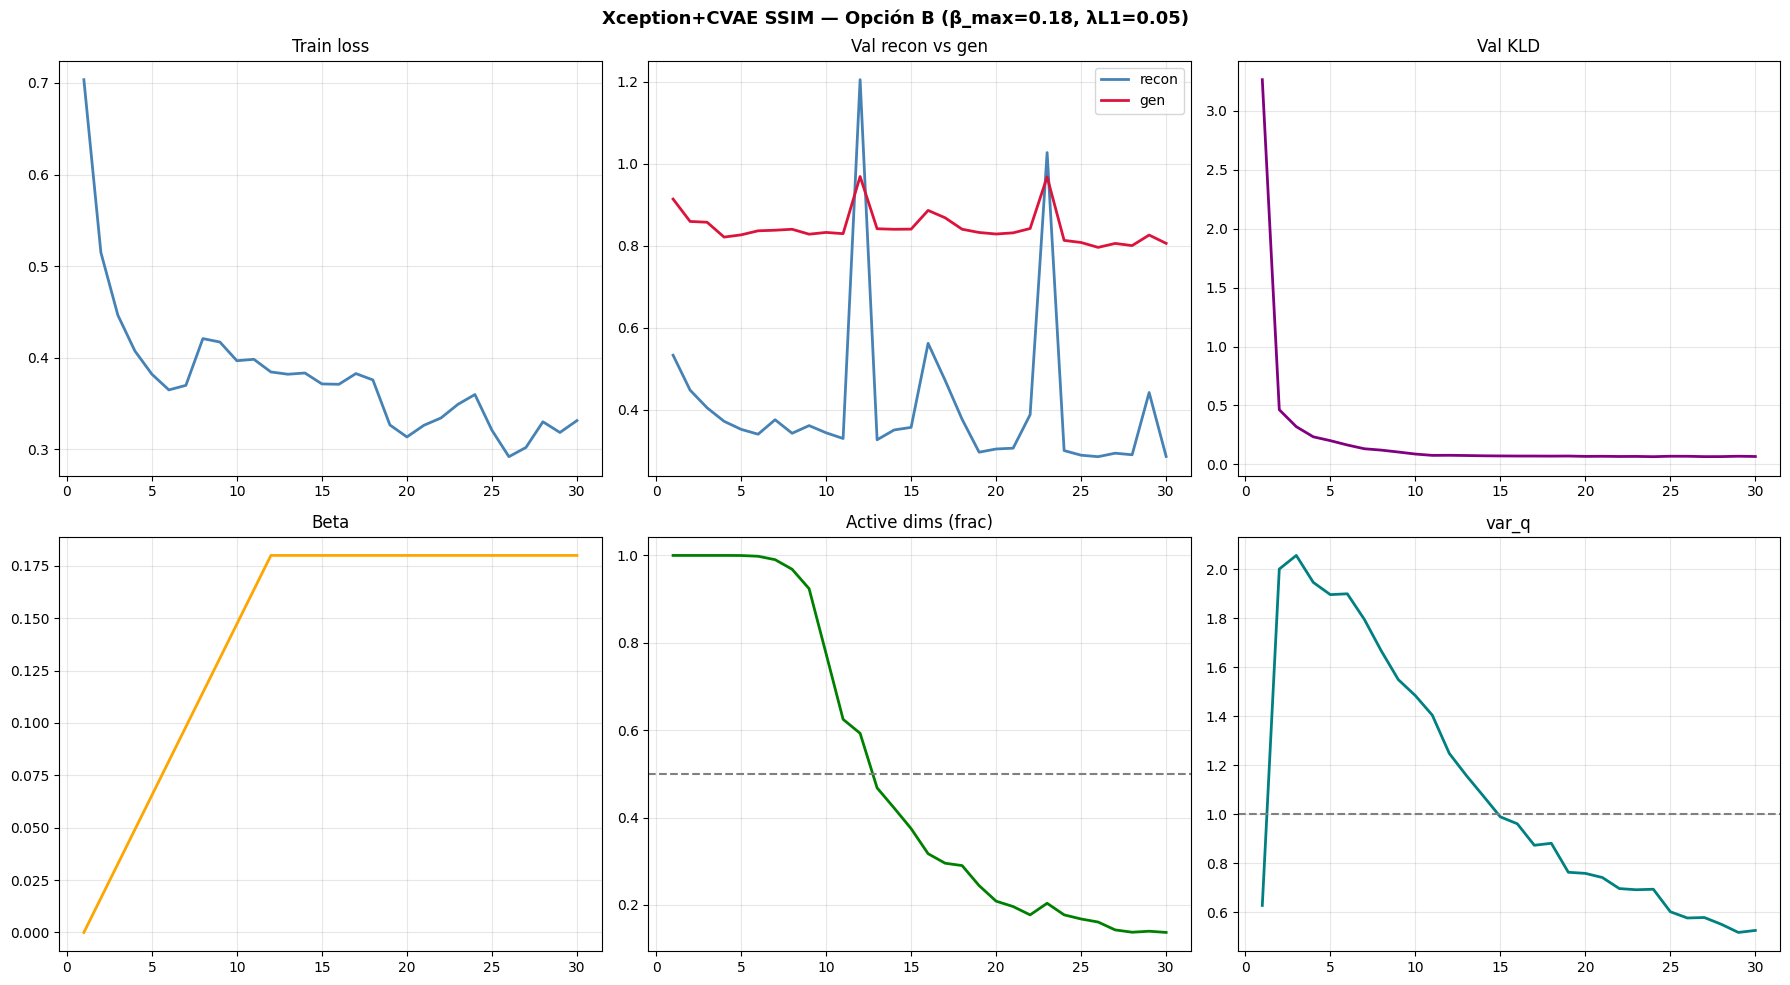

In [12]:
ep = range(1, len(hist["train_loss"]) + 1)
fig, ax = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Xception+CVAE SSIM — Opción B (β_max=0.18, λL1=0.05)", fontsize=13, fontweight="bold")

ax[0,0].plot(ep, hist["train_loss"], color="steelblue", lw=2); ax[0,0].set_title("Train loss"); ax[0,0].grid(alpha=.3)
ax[0,1].plot(ep, hist["val_recon"], label="recon", color="steelblue", lw=2)
ax[0,1].plot(ep, hist["val_gen"],   label="gen",   color="crimson",   lw=2)
ax[0,1].set_title("Val recon vs gen"); ax[0,1].legend(); ax[0,1].grid(alpha=.3)
ax[0,2].plot(ep, hist["val_kld"], color="purple", lw=2); ax[0,2].set_title("Val KLD"); ax[0,2].grid(alpha=.3)
ax[1,0].plot(ep, hist["beta"], color="orange", lw=2); ax[1,0].set_title("Beta"); ax[1,0].grid(alpha=.3)
ax[1,1].plot(ep, hist["kl_active"], color="green", lw=2); ax[1,1].axhline(.5, color="gray", ls="--")
ax[1,1].set_title("Active dims (frac)"); ax[1,1].grid(alpha=.3)
ax[1,2].plot(ep, hist["var_q"], color="teal", lw=2); ax[1,2].axhline(1.0, color="gray", ls="--")
ax[1,2].set_title("var_q"); ax[1,2].grid(alpha=.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "curves_xception_optB.png"), dpi=100)
plt.show()


## 12. Reconstrucciones y generación (carga el best)

Cargado best: /content/outputs/checkpoints/cvae_xception_optB_best.weights.h5


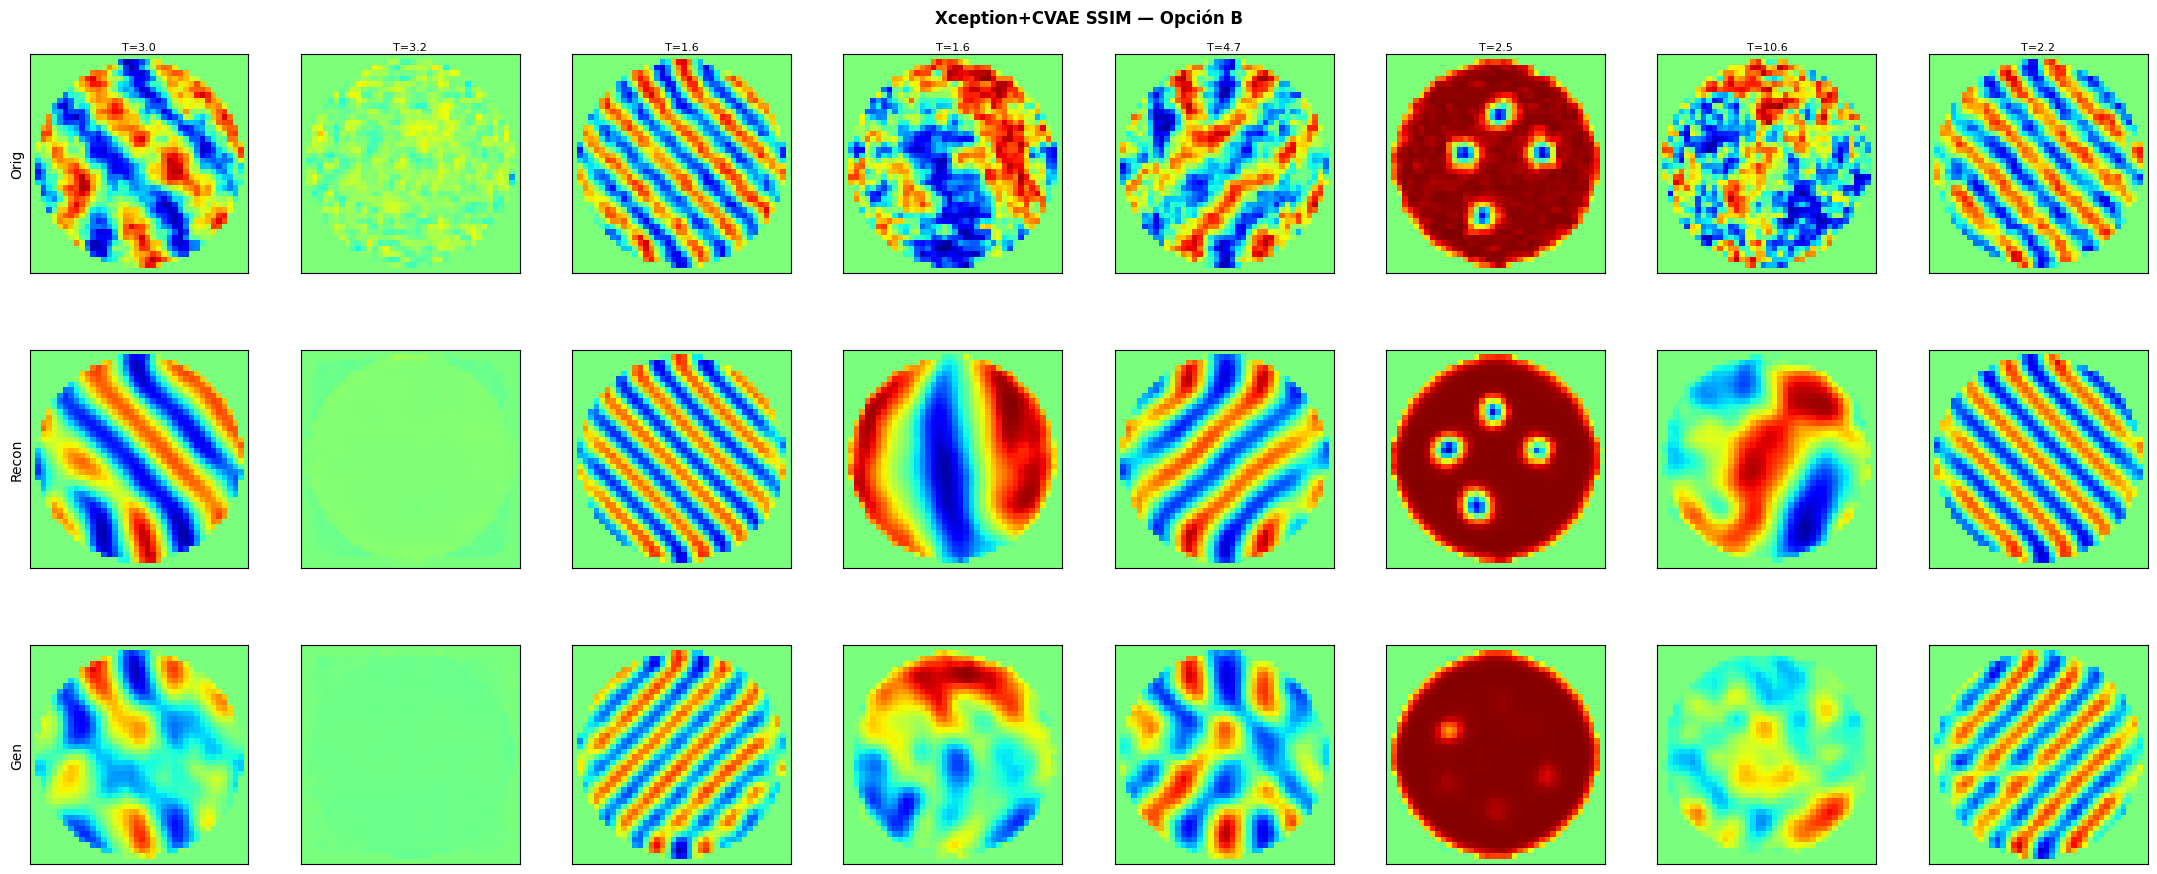

In [13]:
model.load_weights(BEST_CKPT)
print(f"Cargado best: {BEST_CKPT}")

n_show = 8
rng_show = np.random.RandomState(SEED)
show_idx = rng_show.choice(len(idx_val), n_show, replace=False)

fig = plt.figure(figsize=(2.8 * n_show, 2.8 * 3 + 0.6))
gs = plt.GridSpec(3, n_show, figure=fig, wspace=0.08, hspace=0.35,
                  left=0.02, right=0.98, top=0.92, bottom=0.02)
for col, si in enumerate(show_idx):
    real = idx_val[si]
    img_raw = imgs_sub[real:real+1]
    y_in    = params_val[si:si+1]
    img_40  = tf.image.resize(img_raw, (40, 40)).numpy()
    img_xc  = tf.image.grayscale_to_rgb(tf.image.resize(img_raw, (224, 224)))
    x_hat, *_ = model([img_xc, y_in], training=False)
    x_gen     = model.generate(y_in)
    panels = [(img_40[0,:,:,0], "Orig"), (x_hat.numpy()[0,:,:,0], "Recon"), (x_gen.numpy()[0,:,:,0], "Gen")]
    tt = f"T={params_sub_raw[real][0]:.1f}"
    for row, (im, lb) in enumerate(panels):
        a = fig.add_subplot(gs[row, col])
        a.imshow(im, cmap="jet", vmin=-1, vmax=1, interpolation="nearest")
        if col == 0: a.set_ylabel(lb, fontsize=10)
        if row == 0: a.set_title(tt, fontsize=8, pad=3)
        a.set_xticks([]); a.set_yticks([])
fig.suptitle("Xception+CVAE SSIM — Opción B", fontsize=12, fontweight="bold", y=0.97)
plt.savefig(os.path.join(FIG_DIR, "reconstructions_xception_optB.png"), dpi=100)
plt.show()


## 13. Resumen y archivos generados

In [14]:
gr = hist["val_gen"][-1] / (hist["val_recon"][-1] + 1e-8)
print("="*60)
print("RESUMEN — Xception + CVAE + SSIM (Opción B)")
print("="*60)
print(f"  Val recon (last): {hist['val_recon'][-1]:.4f}")
print(f"  Val gen   (last): {hist['val_gen'][-1]:.4f}")
print(f"  Val gen   (best): {min(hist['val_gen']):.4f}")
print(f"  Gap ratio:        {gr:.2f}x")
print(f"  Active dims:      {hist['kl_active'][-1]:.2f}")
print(f"  Var q:            {hist['var_q'][-1]:.3f}")
print("="*60)
print("\nArchivos en /content/outputs:")
for root, _, fnames in os.walk(OUTPUT_DIR):
    for fn in sorted(fnames):
        p = os.path.join(root, fn)
        print(f"  {p}  ({os.path.getsize(p)/1e3:.0f} KB)")


RESUMEN — Xception + CVAE + SSIM (Opción B)
  Val recon (last): 0.2863
  Val gen   (last): 0.8057
  Val gen   (best): 0.7959
  Gap ratio:        2.81x
  Active dims:      0.14
  Var q:            0.526

Archivos en /content/outputs:
  /content/outputs/history_xception_optB.json  (7 KB)
  /content/outputs/param_scaler_xception_optB.pkl  (1 KB)
  /content/outputs/checkpoints/cvae_xception_optB_best.weights.h5  (112271 KB)
  /content/outputs/checkpoints/cvae_xception_optB_last.weights.h5  (112271 KB)
  /content/outputs/figures/curves_xception_optB.png  (146 KB)
  /content/outputs/figures/reconstructions_xception_optB.png  (127 KB)


## 14. (Opcional) Copiar resultados a Google Drive

In [15]:
# from google.colab import drive
# drive.mount("/content/drive")
# DST = "/content/drive/MyDrive/DoctoradoPaper1/cvae_xception_optB"
# os.makedirs(DST, exist_ok=True)
# for root, _, fnames in os.walk(OUTPUT_DIR):
#     for fn in fnames:
#         shutil.copy(os.path.join(root, fn), os.path.join(DST, fn))
# print("Copiado a", DST)
